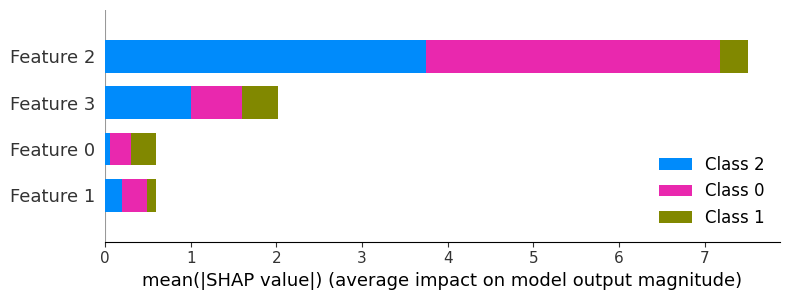

In [10]:
import shap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)

# Обучение логистической регрессии
logistic_model = LogisticRegression(solver='lbfgs')
logistic_model.fit(X_train, y_train)

explainer = shap.Explainer(logistic_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)





Как понимать этот график (интерпретация)?
1. Ранжирование важности
Посмотрите на длину полосок:

petal width (cm) — самый важный признак (самая длинная полоса). Без него модель бы сильно ошибалась.

petal length (cm) — чуть менее важен, но тоже критичен.

sepal width (cm) и sepal length (cm) — имеют небольшое значение. Модель практически не опирается на них, чтобы различить виды ирисов.

Это абсолютно верно для датасета Iris. Длина и ширина лепестков действительно отлично разделяют сорта, а размеры чашелистиков часто пересекаются.

2. Детальный анализ по классам
То, что полоски "разноцветные", говорит о том, что каждый признак важен для предсказания всех трех видов.

Посмотрите на верхнюю полоску (petal width):

Она начинается с синего. Значит, ширина лепестка — самый важный фактор, чтобы отличить Virginica от других.

Потом идет розовый (Setosa). Ширина лепестка также важна для распознавания Setosa.

В конце оливковый (Versicolor).

Тот факт, что все три цвета присутствуют в каждой полоске (примерно равномерно), означает, что модель использует один и тот же признак для различения всех трех классов по очереди.

Точность модели: 1.000
Форма SHAP значений: (45, 4, 3)
Количество классов: 4
Классы: ['setosa' 'versicolor' 'virginica']


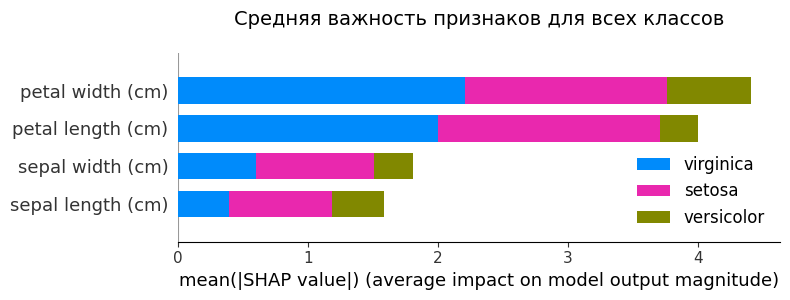

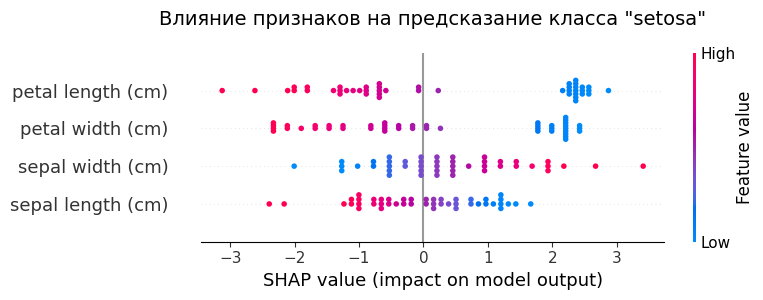

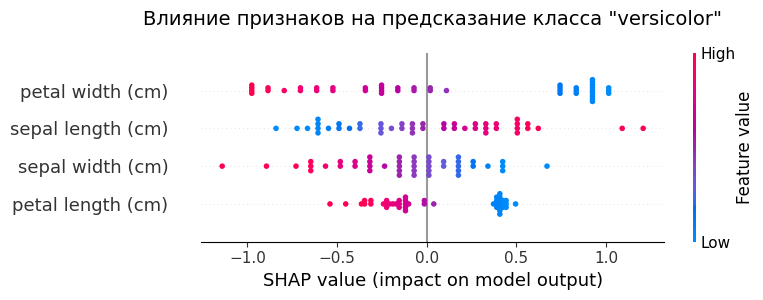

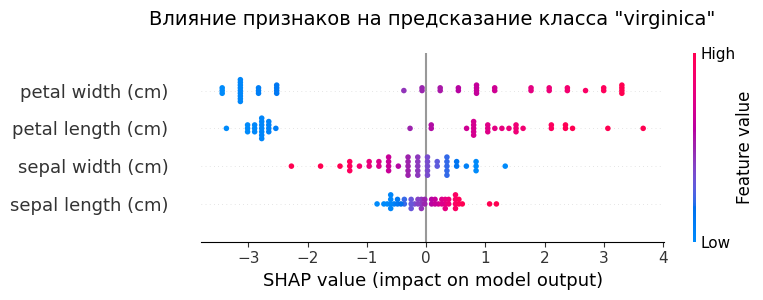

<Figure size 1000x600 with 0 Axes>

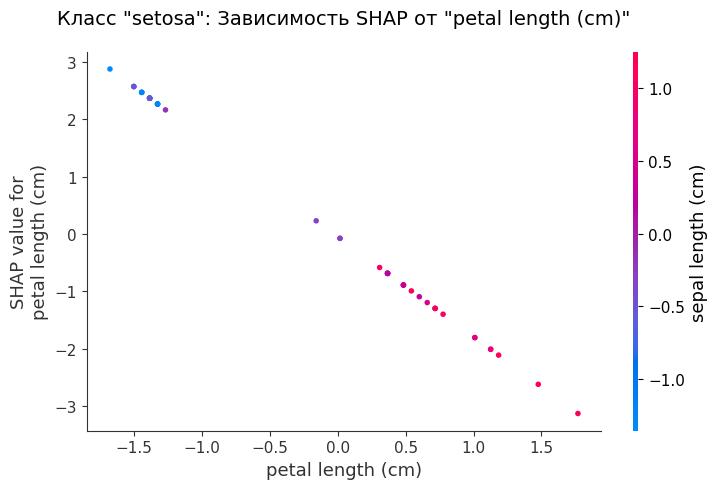

<Figure size 1000x600 with 0 Axes>

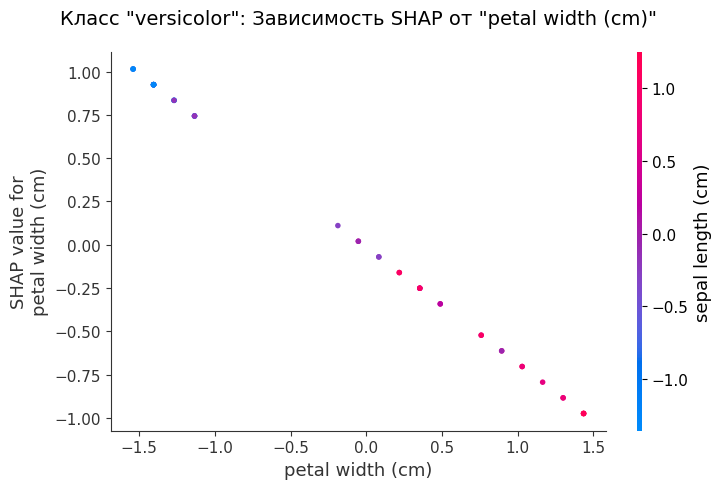

<Figure size 1000x600 with 0 Axes>

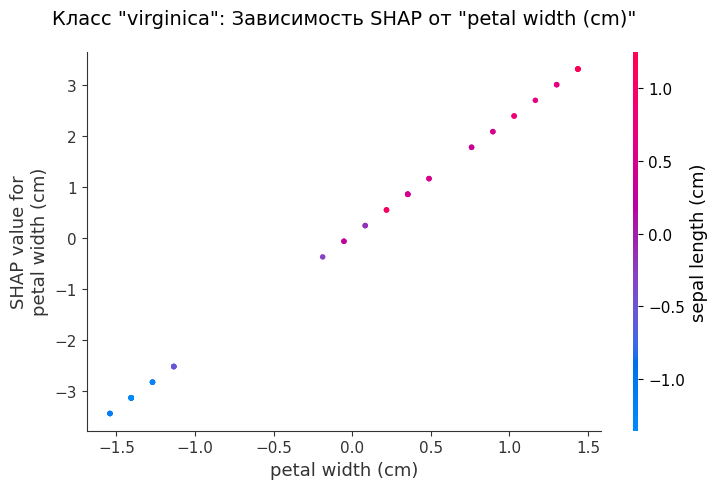

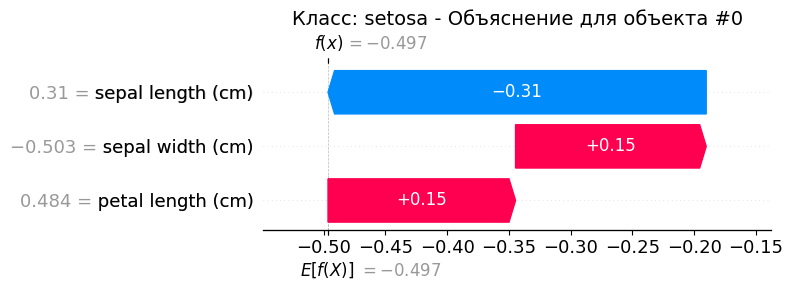

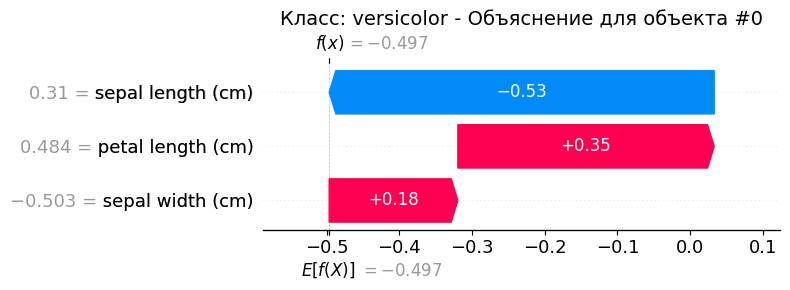

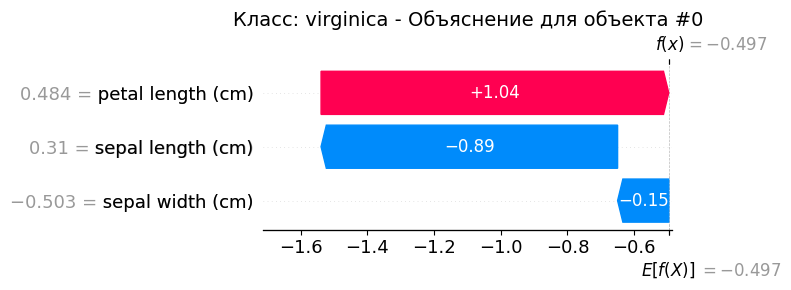

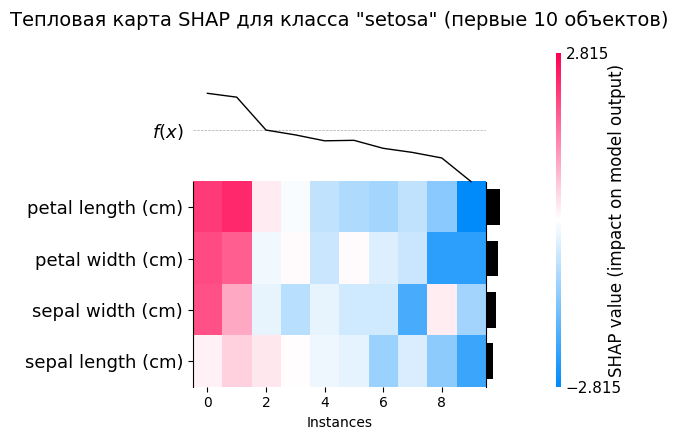

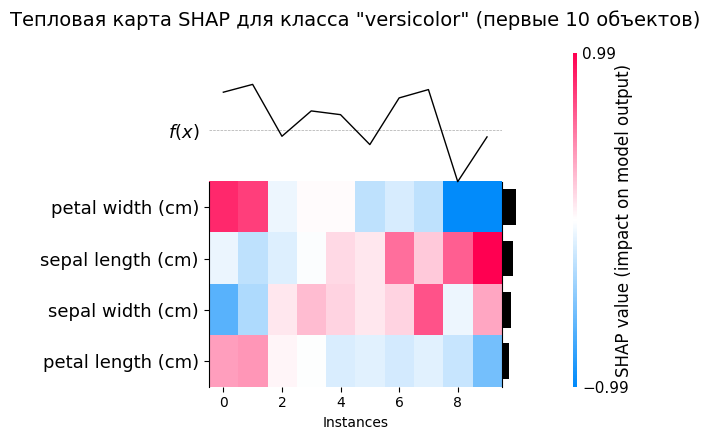

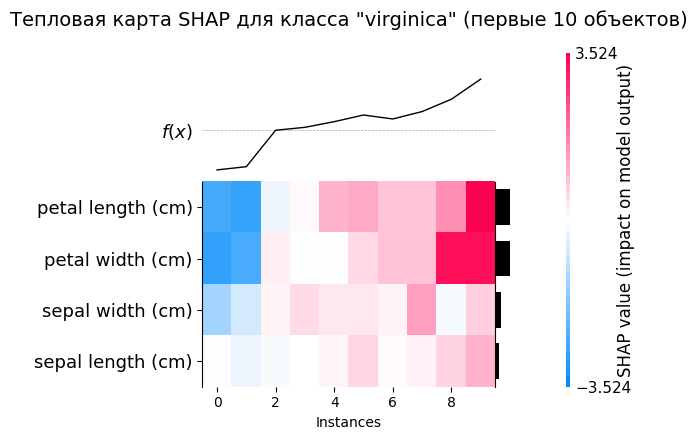

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (3,).

In [11]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Загрузка и подготовка данных
iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)

# 2. Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Обучение модели
logistic_model = LogisticRegression(
    solver='lbfgs', 
    max_iter=1000, 
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train)

print(f"Точность модели: {logistic_model.score(X_test_scaled, y_test):.3f}")
print("=" * 50)

# 4. ПОДПИСИ ДЛЯ ФИЧ
# feature_names = [
#     'Длина чашелистика',
#     'Ширина чашелистика', 
#     'Длина лепестка',
#     'Ширина лепестка'
# ]

feature_names = iris.feature_names

# 5. Создание explainer и расчет SHAP значений
explainer = shap.Explainer(
    logistic_model, 
    X_train_scaled, 
    feature_names=feature_names
)
shap_values = explainer(X_test_scaled)

print(f"Форма SHAP значений: {shap_values.shape}")
print(f"Количество классов: {len(shap_values[0])}")
print(f"Классы: {iris.target_names}")
print("=" * 50)

# ============================================================================
# 6. ВИЗУАЛИЗАЦИЯ (все графики с подписями)
# ============================================================================

# 6.1. Сводный график важности признаков (BAR - для всех классов)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=feature_names,
    class_names=iris.target_names,
    show=False,
    plot_type="bar"
)
plt.title('Средняя важность признаков для всех классов', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 6.2. Детальный сводный график для КАЖДОГО класса (dot plot)
for class_idx, class_name in enumerate(iris.target_names):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values[:, :, class_idx],
        X_test_scaled,
        feature_names=feature_names,
        show=False,
        plot_type="dot"
    )
    plt.title(f'Влияние признаков на предсказание класса "{class_name}"', 
              fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# 6.3. График зависимости для самого важного признака (для каждого класса)
for class_idx, class_name in enumerate(iris.target_names):
    # Берем SHAP значения для одного класса
    shap_values_class = shap_values[:, :, class_idx]
    
    # Определяем самый важный признак
    mean_shap = np.abs(shap_values_class.values).mean(axis=0)
    top_feature_idx = np.argmax(mean_shap)
    
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        top_feature_idx,
        shap_values_class.values,
        X_test_scaled,
        feature_names=feature_names,
        show=False
    )
    plt.title(f'Класс "{class_name}": Зависимость SHAP от "{feature_names[top_feature_idx]}"', 
              fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# 6.4. WATERFALL - объяснение для одного объекта (исправленная версия)
sample_idx = 0

for class_idx, class_name in enumerate(iris.target_names):
    plt.figure(figsize=(10, 6))
    
    # Получаем base_value как скаляр
    base_val = shap_values[sample_idx][class_idx].base_values
    if isinstance(base_val, np.ndarray):
        base_val = base_val[0] if len(base_val) > 0 else 0.0
    
    # Создаем Explanation объект
    exp = shap.Explanation(
        values=shap_values[sample_idx][class_idx].values,
        base_values=base_val,
        data=X_test_scaled[sample_idx],
        feature_names=feature_names
    )
    
    shap.waterfall_plot(
        exp,
        show=False,
        max_display=4
    )
    plt.title(f'Класс: {class_name} - Объяснение для объекта #{sample_idx}', fontsize=14)
    plt.tight_layout()
    plt.show()

# 6.5. ТЕПЛОВАЯ КАРТА (ИСПРАВЛЕННАЯ ВЕРСИЯ)
n_objects = 10

for class_idx, class_name in enumerate(iris.target_names):
    plt.figure(figsize=(14, 8))
    
    # Берем полный объект shap.Explanation для указанного класса
    # Создаем новый Explanation только с нужными данными
    class_shap = shap.Explanation(
        values=shap_values[:, :, class_idx].values,  # значения SHAP для класса
        base_values=shap_values[:, :, class_idx].base_values,  # базовые значения
        data=X_test_scaled,  # данные
        feature_names=feature_names
    )
    
    shap.heatmap_plot(
        class_shap[:n_objects],  # передаем объект Explanation, а не просто массив
        show=False
    )
    plt.title(f'Тепловая карта SHAP для класса "{class_name}" (первые {n_objects} объектов)', 
              fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# 6.6. СРАВНЕНИЕ ВСЕХ КЛАССОВ ДЛЯ ОДНОГО ОБЪЕКТА (bar plot)
sample_idx = 0
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(feature_names))
width = 0.25
multiplier = 0

for class_idx, class_name in enumerate(iris.target_names):
    offset = width * multiplier
    values = shap_values[sample_idx][class_idx].values
    ax.bar(x + offset, values, width, label=f'Класс {class_name}')
    multiplier += 1

ax.set_ylabel('SHAP значение', fontsize=12)
ax.set_xlabel('Признаки', fontsize=12)
ax.set_title(f'Вклад признаков для объекта #{sample_idx} по каждому классу', fontsize=14)
ax.set_xticks(x + width, feature_names)
ax.legend(loc='upper right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# 6.7. ВАЖНОСТЬ ПРИЗНАКОВ (усредненная по всем классам)
mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 1))

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(mean_abs_shap)
plt.barh(np.array(feature_names)[sorted_idx], mean_abs_shap[sorted_idx])
plt.xlabel('Среднее |SHAP значение|', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Общая важность признаков (усредненно по всем классам)', fontsize=14)
plt.tight_layout()
plt.show()

# 6.8. ПРОСТОЙ BAR PLOT ДЛЯ ОДНОГО ОБЪЕКТА (все классы на одном графике)
sample_idx = 1
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Вклад признаков для объекта #{sample_idx} по классам', fontsize=16)

for class_idx, class_name in enumerate(iris.target_names):
    values = shap_values[sample_idx][class_idx].values
    colors = ['red' if v < 0 else 'green' for v in values]
    axes[class_idx].barh(feature_names, values, color=colors)
    axes[class_idx].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[class_idx].set_title(f'Класс: {class_name}')
    axes[class_idx].set_xlabel('SHAP значение')
    
plt.tight_layout()
plt.show()

# 6.9. ПРЕДСКАЗАНИЯ МОДЕЛИ
predicted_classes = logistic_model.predict(X_test_scaled)
predicted_proba = logistic_model.predict_proba(X_test_scaled)

print("\n" + "=" * 50)
print("ПРИМЕР ПРЕДСКАЗАНИЙ ДЛЯ ПЕРВЫХ 5 ОБЪЕКТОВ:")
print("=" * 50)
for i in range(5):
    true_class = iris.target_names[y_test[i]]
    pred_class = iris.target_names[predicted_classes[i]]
    proba = predicted_proba[i]
    print(f"Объект {i}: Истинный: {true_class}, "
          f"Предсказанный: {pred_class}, "
          f"Вероятности: {proba.round(3)}")

# 6.10. ДОПОЛНИТЕЛЬНО: Средние SHAP значения для каждого признака по классам
print("\n" + "=" * 50)
print("СРЕДНИЕ SHAP ЗНАЧЕНИЯ ПО КЛАССАМ:")
print("=" * 50)

for class_idx, class_name in enumerate(iris.target_names):
    print(f"\nКласс {class_name}:")
    mean_shap = shap_values[:, :, class_idx].values.mean(axis=0)
    for feat, val in zip(feature_names, mean_shap):
        print(f"  {feat}: {val:.3f}")